In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


This will mount your Google Drive, and you can access your files from the /content/drive/My Drive/ directory.

In [ ]:
dataset_path = '/content/drive/My Drive/data science class 5 to 6.30/Machine Learning Dataset/'


In [ ]:
# Install the unrar tool in Colab to extract .rar files
!apt-get install unrar


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


Purpose: This installs the unrar tool, which is necessary for extracting .rar files in a Colab environment.


In [ ]:
# Define the path to your rar file and extraction destination
dataset_path = '/content/drive/My Drive/data science class 5 to 6.30/Machine Learning Dataset/'
rar_file = dataset_path + 'dogs_vs_cats.rar'  # Path to the .rar file
extract_folder = '/content/drive/My Drive/data science class 5 to 6.30/Machine Learning Dataset/dogs_vs_cats/'  # Destination for extraction


Purpose: Set the path for your .rar file and specify where you want to extract the contents.

In [ ]:
# Extract the contents of the rar file to the specified folder
!unrar x "{rar_file}" "{extract_folder}"



UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/My Drive/data science class 5 to 6.30/Machine Learning Dataset/dogs_vs_cats.rar


Would you like to replace the existing file /content/drive/My Drive/data science class 5 to 6.30/Machine Learning Dataset/dogs_vs_cats/dogs_vs_cats/test/cats/cat.10.jpg
 34315 bytes, modified on 2019-10-13 14:27
with a new one
 34315 bytes, modified on 2019-10-13 14:27

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit Q

Program aborted


Purpose: This command extracts the .rar file into the destination folder dogs_vs_cats/ using unrar.

In [ ]:
# Verify the extraction by listing files in the destination folder
import os
extracted_files = os.listdir(extract_folder)
print("Extracted files:", extracted_files)


Extracted files: ['dogs_vs_cats']


Purpose: List the files that were extracted to ensure that the dogs and cats folders are present.

**Load the dataset**

In [ ]:
# Import TensorFlow to work with the dataset
import tensorflow as tf

# Load the training dataset (dogs and cats images)
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    extract_folder +'dogs_vs_cats/train',  # Path to the extracted folder containing 'dogs' and 'cats' directories ##/train added later
    image_size=(256, 256),  # Resize images to 256x256 pixels
    batch_size=32,  # Number of images per batch
    label_mode='binary'  # Binary classification: 0 for dogs, 1 for cats
)

# Load the test dataset (assuming same structure for validation data)
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    extract_folder  +'dogs_vs_cats/test' ,  # Path to the extracted folder containing 'dogs' and 'cats' directories
    image_size=(256, 256),  # Resize images to 256x256 pixels
    batch_size=32,  # Number of images per batch
    label_mode='binary'  # Binary classification: 0 for dogs, 1 for cats
)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


- TensorFlow is a popular machine learning framework used for tasks like deep learning and image classification
- batch_size=32:Defines the number of images loaded and processed together in one batch.

Purpose: This loads the dataset for training and validation by reading the images from the dogs and cats folders inside the extracted folder. The dataset is labeled as binary (dog = 0, cat = 1).

 **Preview the data**

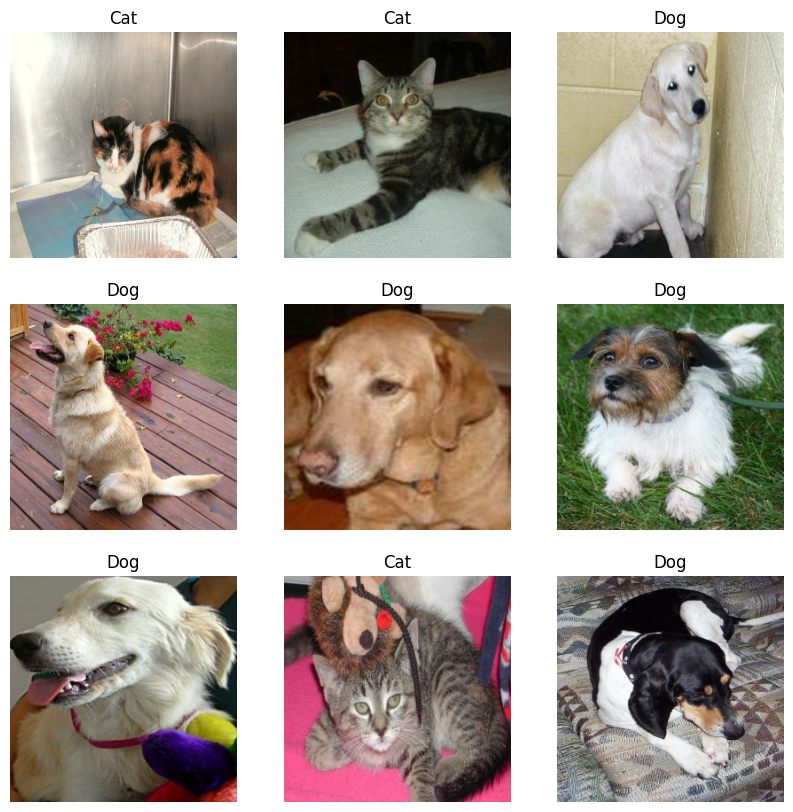

In [ ]:
# Preview a batch of images from the training dataset
import matplotlib.pyplot as plt

# Get the first batch of images and labels
for images, labels in train_dataset.take(1):  # Take the first batch
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Display 9 images from the batch
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert the image tensor to uint8 for display
        plt.title("Cat" if labels[i] == 0 else "Dog")  # Label the image   # i change it to 0 from 1
        plt.axis("off")
    plt.show()


Purpose: This previews a batch of images to make sure the dataset is loaded correctly. It displays the first 9 images and labels them as "Cat" or "Dog".

**Build the CNN model**

In [ ]:
# Import necessary TensorFlow modules
import tensorflow as tf

# Define a simple Convolutional Neural Network (CNN) model
model = tf.keras.Sequential([
    # Normalize the images to the range [0, 1]
    tf.keras.layers.Rescaling(1./255, input_shape=(256, 256, 3)),

    # Convolutional layer with 32 filters and 3x3 kernel, followed by max pooling
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Convolutional layer with 64 filters and 3x3 kernel, followed by max pooling
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Convolutional layer with 128 filters and 3x3 kernel, followed by max pooling
    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Flatten the 2D outputs into 1D
    tf.keras.layers.Flatten(),

    # Fully connected layer with 128 units and ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer with 1 unit and sigmoid activation for binary classification
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile the model with Adam optimizer and binary crossentropy loss function
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Show model summary to check architecture
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,839,105 (56.61 MB)

 Trainable params: 14,839,105 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

- Purpose: This code defines a simple CNN model:
- Convolutional layers: To extract features from the images.
- MaxPooling layers: To downsample the images and reduce - spatial dimensions.
- Flatten layer: To convert 2D features into a 1D vector - for the fully connected layers.
- Dense layers: Fully connected layers for classification.
- Sigmoid output layer: To output a probability (for binary classification).



**Train the model**

In [ ]:
# Train the model using the training and validation datasets
history = model.fit(
    train_dataset,  # Training dataset
    validation_data=validation_dataset,  # Validation dataset
    epochs=1  # Number of epochs for training
)


625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.7877 - loss: 0.4482 - val_accuracy: 0.8008 - val_loss: 0.4343


Purpose: This trains the model using the training and validation datasets for 1 epochs. You can increase the number of epochs based on performance.


**Evaluate the model**

In [ ]:
# Evaluate the model's performance on the validation dataset
test_loss, test_acc = model.evaluate(validation_dataset)
print(f"Test Accuracy: {test_acc}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - accuracy: 0.7957 - loss: 0.4348
Test Accuracy: 0.8008000254631042


Purpose: This evaluates the trained model on the validation set and prints out the test accuracy. It gives you an idea of how well the model is performing.

**Visualize training history**

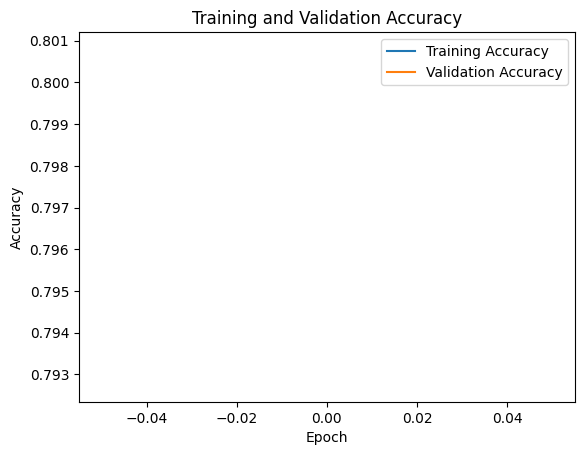

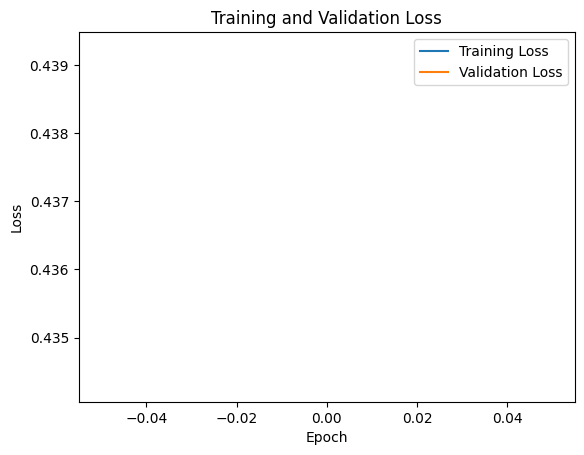

In [ ]:
# Plot the training and validation accuracy over epochs
import matplotlib.pyplot as plt

# Plot the accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Plot the loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


Purpose: This visualizes the training and validation accuracy/loss to check how the model is performing over time. If the training accuracy is much higher than the validation accuracy, it may indicate overfitting

****Make predictions****

In [ ]:
# Example: Predict on a new image
import numpy as np
from tensorflow.keras.preprocessing import image

# Load a sample image from your Google Drive
img_path = '/content/drive/My Drive/data science class 5 to 6.30/Machine Learning Dataset/dogs_vs_cats/sample_image.jpg'  # Replace with your image path
img = image.load_img(img_path, target_size=(256, 256))  # Resize image
img_array = image.img_to_array(img)  # Convert image to array
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Normalize

# Predict the class
prediction = model.predict(img_array)
if prediction[0] > 0.5:
    print("The image is a Cat.")
else:
    print("The image is a Dog.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
The image is a Dog.


Purpose: This code allows you to predict whether a new image is a dog or a cat using the trained model. Make sure to update the image path.


Next Steps:
Improve Model: Experiment with more complex models, fine-tune the hyperparameters, or use data augmentation to improve model performance.
Save the Model: After training, you can save the model to Google Drive for later use.

In [ ]:
# Save the model to your Google Drive
model.save('/content/drive/My Drive/data science class 5 to 6.30/Machine Learning Dataset/dogs_vs_cats_model.h5')
